In [1]:
import torch
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import ticker 

torch.manual_seed(42)

from dataclass import dataset
import mcmc

$$
\begin{array}{|c|l|c|c|}
\hline
 & \text{Reaction} & \text{Stoichiometry} & \text{Rate} \\
\hline
\text{Colonization} & \emptyset \to E & +1 & \alpha \\
\hline
\text{Replication} & E \to 2E & +1 & \mu E \\
\hline
\text{Competition} & E \to \emptyset & -1 & \left(\frac{\mu}{K}\right) E^2 \\
\hline
\text{Expulsion} & E \to \emptyset & -1 & dE \\
\hline
\end{array}
$$


In [2]:
# Loading the synthetic dataset
dseed = 0
df = pd.read_csv('synthetic_data/synth_seed{}.csv'.format(dseed))
df

,Time,Counts,Dilution
0,24,0,20.0
1,24,0,20.0
2,24,0,20.0
3,24,0,20.0
4,24,0,20.0
...,...,...,...
495,216,55,2000.0
496,216,74,2000.0
497,216,63,2000.0
498,216,58,2000.0


In [3]:
#Loading the ground truth

gt = pd.read_csv('synthetic_data/gt_map.csv', header=None, delim_whitespace=True).to_numpy()
gt = torch.tensor(gt[gt[:,0]==dseed][0,1:]).float()
gt

tensor([5.0000e-02, 2.5000e-01, 2.0000e+05, 1.0000e-01])

In [4]:
# The dataset need to be send to the `dataset` class
Ts     = df['Time'].to_numpy()
counts = df['Counts'].to_numpy()
dils   = df['Dilution'].to_numpy()
data = dataset(Ts,counts,dils)
print('It should run on: ',data.device)


logposterior = lambda x: mcmc.logposterior(x,data) 

In [ ]:
lp_gt = logposterior(gt.to(data.device))
lp_gt

tensor(-1950.1710, device='cuda:0', dtype=torch.float64)

In [ ]:
params = mcmc.prior.sample()

params = data.ode_initialization(params)
lp = logposterior(params)

Initializing using mass-action similarity


  2%|▏         | 10/500 [00:06<05:46,  1.41it/s]

gradient: 46891.30078125 21314.65591251567


  4%|▍         | 20/500 [00:13<05:15,  1.52it/s]

gradient: 38765.234375 14613.44139212849


...

gradient: 0.005977095104753971 0.48244911927228507


 98%|█████████▊| 490/500 [03:38<00:04,  2.45it/s]

gradient: 0.005879388656467199 0.4824464711240562


100%|██████████| 500/500 [03:42<00:00,  2.25it/s]

gradient: 0.005782834254205227 0.4824438762780875


/tmp/ipykernel_6166/3332176620.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(Ts,np.log10(naive_n))


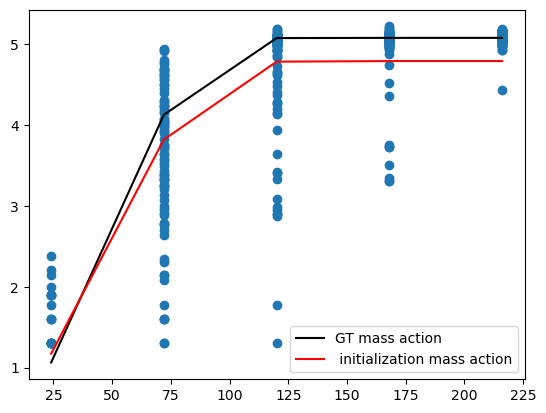

In [ ]:
### Does the initialization makes sense?

t = df['Time'].to_numpy()
naive_n = df['Counts'].to_numpy()*df['Dilution'].to_numpy()

import simulator
import numpy as np

y = simulator.integrate_mass_action(gt,Ts).reshape(-1)
plt.plot(Ts,np.log10(y),color='k',label='GT mass action')
y = simulator.integrate_mass_action(params.cpu(),Ts).reshape(-1)
plt.plot(Ts,np.log10(y),color='r',label=' initialization mass action')

plt.scatter(Ts,np.log10(naive_n))
plt.legend()
plt.savefig('Initialization_result.png',dpi=600)

In [ ]:
initial_guess=params 

n_burn1 = 20#0
n_burn2 = 50#0
n_mcmc = 2000 

    
dim = 4
params = initial_guess.clone().detach()#.double()
lp = logposterior(params)

mcmc_params = torch.zeros((n_burn1+n_burn2+n_mcmc,dim),device=params.device)
mcmc_lps = []

# scalar proposal for burn1

total_steps = n_burn1 + n_burn2 + n_mcmc

In [ ]:
greedy = False
for s in tqdm(range(total_steps)):
    greedy = s < n_burn1
    adapt = (not greedy) and (s < n_burn1+n_burn2)

    # ---- Step and store ---
    sample_history = (mcmc_params[n_burn1-2:s]) if adapt else None
    params, lp = mcmc.next_MCMC_sample(logposterior, params, lp, 
                                       greedy=greedy, adapt=adapt,
                                       sample_history=sample_history)
    mcmc_params[s] = 1*params
    mcmc_lps.append(lp.item())

    if (s + 1) % 10 == 0:
        print(f"[{s+1}] lp = {lp.item():.3f}")
        print(params.cpu())
        print('If it is running on GPU it should say CUDA:', params.device )

        #It will save the full chain so far
        posterior_samples = np.array([s.cpu().numpy() for s in mcmc_params])
        np.savetxt('samples_so_far.csv',posterior_samples)





  0%|          | 0/2500 [00:00<?, ?it/s]


TypeError: vstack() got an unexpected keyword argument 'dim'

In [ ]:
posterior_samples = torch.stack(mcmc_params[-n_mcmc:]).cpu().numpy()

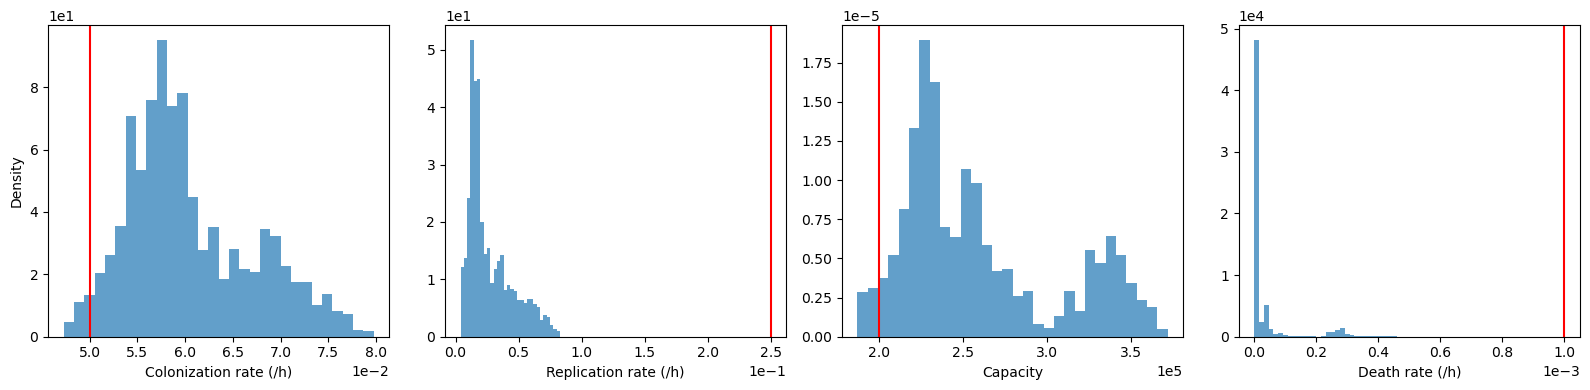

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Colonization rate (/h)','Replication rate (/h)','Capacity','Death rate (/h)']
for i in range(4):
    ax[i].hist(posterior_samples[:, i], bins=30, density=True, alpha=0.7)
    ax[i].set_xlabel(titles[i])
    ax[i].axvline(gt[i].item(),color='r')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
[axi.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) for axi in ax]
[axi.ticklabel_format(style='sci', axis='x', scilimits=(0, 0)) for axi in ax]

ax[0].set_ylabel('Density')
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Log posterior')

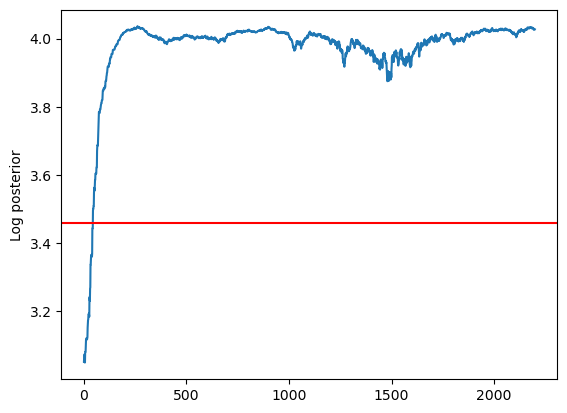

In [ ]:
plt.plot(mcmc_lps)
plt.axhline(lp_gt.item(),color='r')
plt.ylabel('Log posterior')